# 量子传感仿真平台测试 — `sqc` 版本

对标 [`Simulation.ipynb`](Simulation.ipynb)，本 notebook 用重构后的 `sqc.*` API 演示各 sensing protocol。

**主要差异**：
- 顶层 API 从 `src.protocal.Protocal(type=N)` switch-case 改为独立的 `*Experiment` 类（`RabiExperiment`、`RamseyExperiment`、…）。
- 信号重建从 `Analysis.<method>()` 改为独立的 `*Reconstruction` 类。
- 所有时间轴从全局 `sqc.config.CONFIG` 派生（`dt = 1 / sample_rate`），不再用 `np.linspace`。
- 实验返回统一的 `ExperimentResult`（`.data` / `.axes` / `.metadata` / `.config`），便于序列化。

**关于兼容性**：sqc 的 `TransmonQubit` 是 `src.qubit.TransmonQubit` 的现代等价实现，构造签名一致。

## 0. 环境与全局配置

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal

print(f"AWG sample_rate = {CONFIG.awg.sample_rate} GSa/s  →  dt = {CONFIG.awg.dt} ns")
print(f"t_rabi  : start={CONFIG.pulse.t_rabi[0]:.2f}  end={CONFIG.pulse.t_rabi[-1]:.2f}  N={len(CONFIG.pulse.t_rabi)}")
print(f"t_global: start={CONFIG.pulse.t_global[0]:.2f}  end={CONFIG.pulse.t_global[-1]:.2f}  N={len(CONFIG.pulse.t_global)}")
print(f"tau_list: N={len(CONFIG.pulse.tau_list)}")
print(f"Transmon defaults: EC/h={CONFIG.transmon.EC} GHz, EJ/h={CONFIG.transmon.EJ} GHz")

AWG sample_rate = 2.0 GSa/s  →  dt = 0.5 ns
t_rabi  : start=0.00  end=9.50  N=20
t_global: start=-50.00  end=399.50  N=900
tau_list: N=500
Transmon defaults: EC/h=0.2 GHz, EJ/h=15.0 GHz


## 1. Rabi 振荡 — `RabiExperiment`

对应原 `Protocal(type=0)`。施加恒定振幅驱动脉冲，测量 $p_e(t)$。

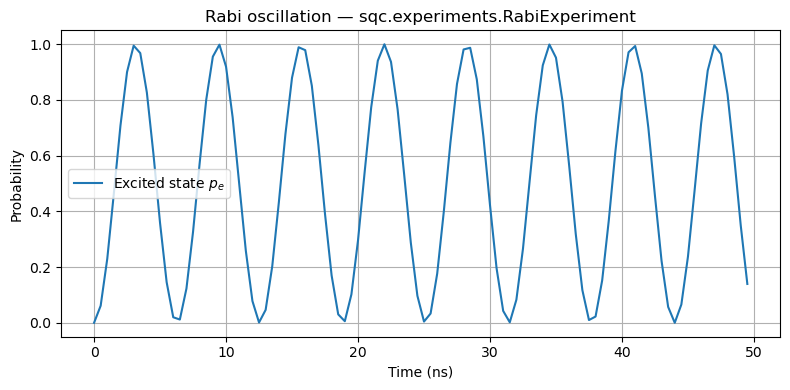

In [2]:
from sqc.experiments.rabi import RabiExperiment

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    state=0,
    n_levels=2,
)

t_rabi = CONFIG.pulse.make_time(0, 50)  # ns
rabi_exp = RabiExperiment(qubit=qubit, t_rabi=t_rabi)
rabi_result = rabi_exp.run()

p_e = rabi_result.expect[0]

plt.figure(figsize=(8, 4))
plt.plot(t_rabi, p_e, label="Excited state $p_e$")
plt.xlabel("Time (ns)")
plt.ylabel("Probability")
plt.title("Rabi oscillation — sqc.experiments.RabiExperiment")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

## 2. Ramsey 干涉 — `RamseyExperiment` + `RamseyUnwrapReconstruction`

对应原 `Protocal(type=1)`。$\pi/2$ — $\tau$ — $\pi/2$ 序列测自由演化期间积累的相位，由相位演化反推磁场 $B(t)$。

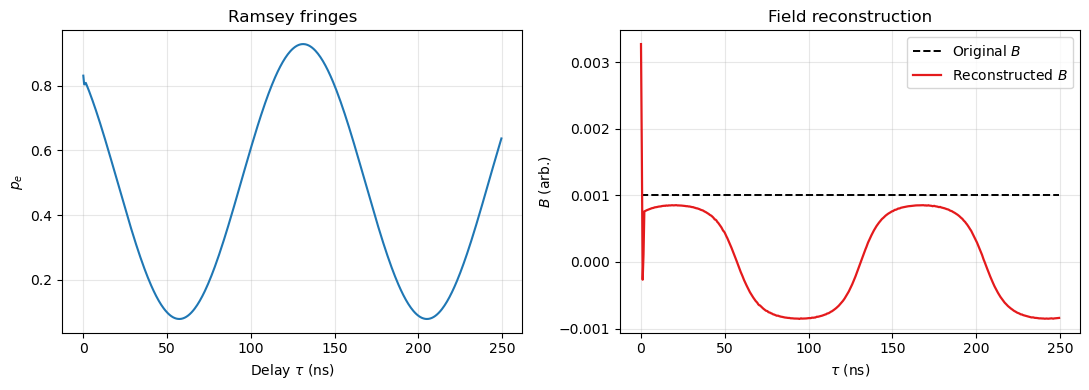

In [4]:
from sqc.experiments.ramsey import RamseyExperiment
from sqc.reconstruction.wiener import RamseyUnwrapReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    state=0,
    n_levels=2,
)
# 移到敏感工作点（dω/dΦ 最大处附近）
Phi_work = qubit._spec.optimal_work_point() if hasattr(qubit._spec, "optimal_work_point") else 0.25
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=Phi_work, n_levels=2,
)

ramsey_exp = RamseyExperiment(qubit=qubit)  # 用默认 sinusoidal flux
ramsey_result = ramsey_exp.run()

tau_list = ramsey_result.axes["tau"]
p_e_list = ramsey_result.data["p_e"]
B_true = ramsey_result.data["flux_samples"]

rec = RamseyUnwrapReconstruction(qubit=qubit)
B_rec = rec.reconstruct(ramsey_result)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tau_list, p_e_list, color="#1f77b4")
axes[0].set_xlabel(r"Delay $\tau$ (ns)"); axes[0].set_ylabel(r"$p_e$")
axes[0].set_title("Ramsey fringes"); axes[0].grid(alpha=0.3)

axes[1].plot(ramsey_result.axes["t_flux"], B_true, "k--", lw=1.4, label="Original $B$")
axes[1].plot(tau_list, B_rec, color="#e41a1c", lw=1.6, label="Reconstructed $B$")
axes[1].set_xlabel(r"$\tau$ (ns)"); axes[1].set_ylabel("$B$ (arb.)")
axes[1].set_title("Field reconstruction"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 3. 差分回波（Differential Echo）— `DiffEchoExperiment` + `DiffEchoReconstruction`

对应原 `Protocal(type=2)`。多次回波叠加增强弱信号灵敏度。

In [ ]:
from sqc.experiments.echo import DiffEchoExperiment
from sqc.reconstruction.wiener import DiffEchoReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.25, n_levels=2,
)

echo_exp = DiffEchoExperiment(qubit=qubit, k=5)
echo_result = echo_exp.run()

rec = DiffEchoReconstruction(qubit=qubit, t_int=echo_exp.t_int, k=echo_exp.k)
B_rec = rec.reconstruct(echo_result)

tau = echo_result.axes["tau"]
plt.figure(figsize=(8, 4))
plt.plot(tau, echo_result.data["flux_samples"], "k--", label="Original $B$")
plt.plot(tau, B_rec, color="#e41a1c", label="Reconstructed $B$ (DiffEcho)")
plt.xlabel(r"$\tau$ (ns)"); plt.ylabel("$B$")
plt.title(f"Differential echo (k={echo_exp.k})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. 瞬态磁场感测 — `TransientSensingExperiment` + `WienerReconstruction`

对应原 `Protocal(type=4)`。滑动 Ramsey 控制脉冲扫过磁场信号，用 Wiener 反卷积从 $\Delta p$ 还原 $B(t)$。

qubit frequency: 23.75209505361109
Optimal work point flux: 0.9553166181245093
Sliding measurement with 439 samples took 16.11 seconds
Sliding measurement with 439 samples took 8.14 seconds


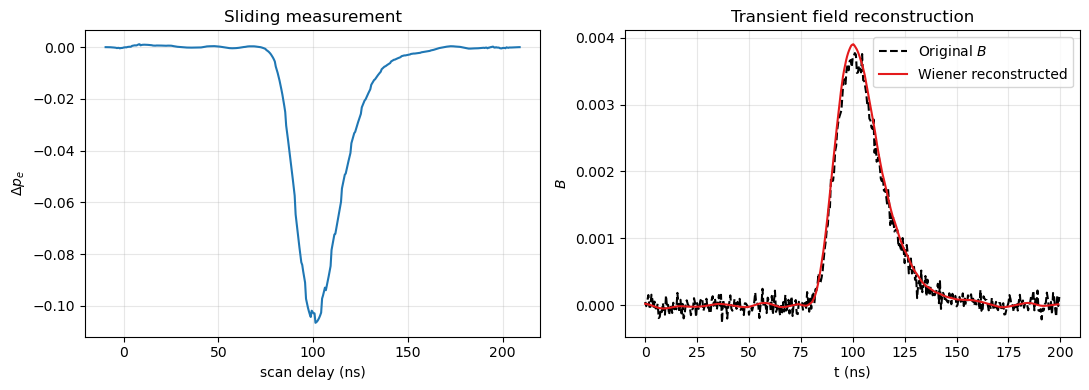

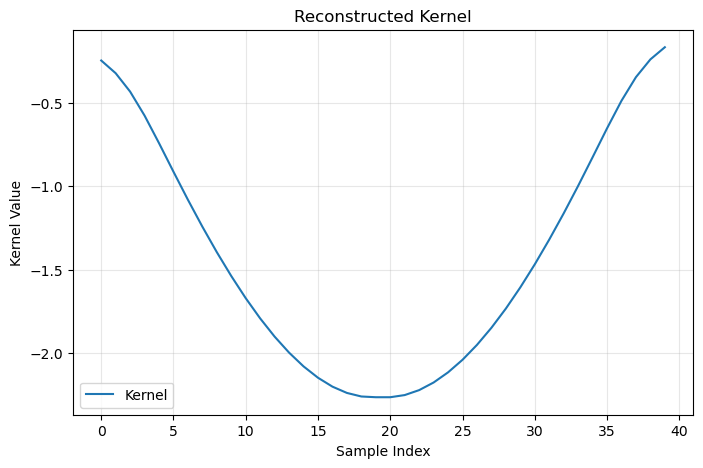

In [2]:
from sqc.experiments.transient import TransientSensingExperiment
from sqc.reconstruction.wiener import WienerReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.9553, n_levels=2,
)

# freq
print(f"qubit frequency: {qubit.frequency}")
print(f"Optimal work point flux: {qubit.optimal_work_point()}")
trans_exp = TransientSensingExperiment(qubit=qubit)
trans_result = trans_exp.run()
kernel = trans_result.data["kernel"]

rec = WienerReconstruction(lambda_reg=CONFIG.reconstruction.lambda_reg)
B_rec_signal = rec.reconstruct(trans_result, kernel=trans_result.data["kernel"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trans_result.axes["scan"], trans_result.data["delta_p"], color="#1f77b4")
axes[0].set_xlabel("scan delay (ns)"); axes[0].set_ylabel(r"$\Delta p_e$")
axes[0].set_title("Sliding measurement"); axes[0].grid(alpha=0.3)

axes[1].plot(trans_result.axes["t_flux"], trans_result.data["flux_samples"], "k--", label="Original $B$")
axes[1].plot(B_rec_signal.t_list, B_rec_signal.signal, color="#e41a1c", label="Wiener reconstructed")
axes[1].set_xlabel("t (ns)"); axes[1].set_ylabel("$B$")
axes[1].set_title("Transient field reconstruction"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(len(kernel)), kernel, label="Kernel")
plt.xlabel("Sample Index")
plt.ylabel("Kernel Value")
plt.title("Reconstructed Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Cryoscope 完整 pipeline — 标定→测量→重建

对应原 `Protocal(type=5/6)` 和 `Analysis.get_signal_from_cryoscope`。

**三步流程**：
1. **标定** (`FluxResponseCalibration(method="cryoscope")`) — 扫描方波高度 $h$，IQ 读出建立 $arphi(h)$ 查找表
2. **测量** (`CryoscopeExperiment`) — 施加待测波形，扫描截断延迟 $t_d$，测 $arphi(t_d)$
3. **重建** (`CryoscopeReconstruction`) — $darphi/dt \cdot 	au 	o arphi_{	ext{cal}}^{-1} 	o h(t)$

> 之前为 stub（`NotImplementedError`），现已全部实现。


qubit frequency: 2.839 GHz
--- Step 1: Calibration ---
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.64571412-0.29575146j]
 [-0.12757191+0.68857428j]
 [ 0.07182256-0.00409143j]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.65741103-0.2685823j ]
 [-0.21289173+0.66725438j]
 [ 0.07075467+0.010806j  ]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.66810728-0.24057116j]
 [-0.29597923+0.63488938j]
 [ 0.06656411+0.02528182j]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.67773634-0.21175559j]
 [-0.37529888+0.59158056j]
 [ 0.05934426+0.03865846j]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.68622863-0.18215964j]
 [-0.44933212+0.53763066j]
 [ 0.04934656+0.050269j  ]]
State at t=10.0

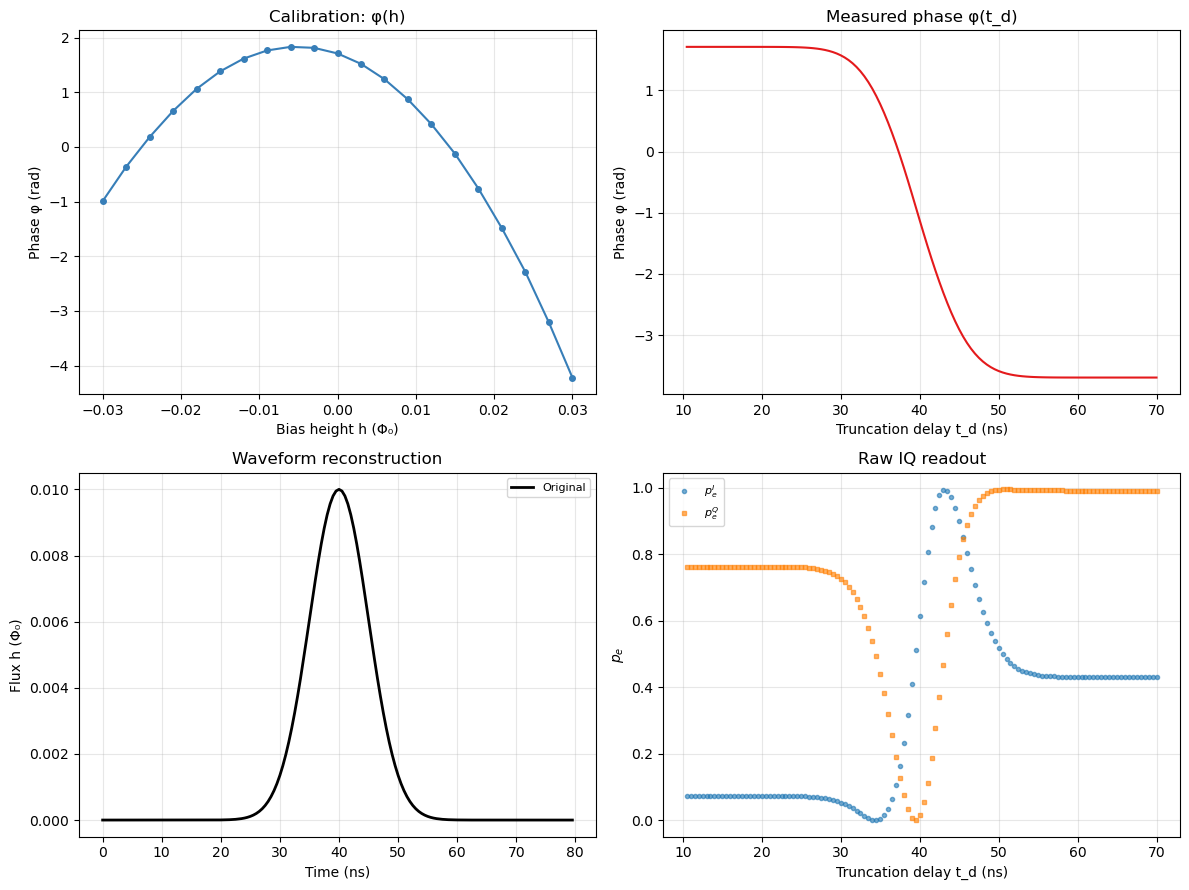

--- Reconstruction quality ---
  calib_inverse     RMSE = 46516092.104800 Φ₀
  SG_diff           RMSE = 43.058187 Φ₀
  diff              RMSE = 44.458119 Φ₀


In [ ]:
%load_ext autoreload
%autoreload 2
# === Cryoscope 完整 pipeline：标定 → 测量 → 重建 ===
from sqc.calibration.flux_response import FluxResponseCalibration
from sqc.experiments.cryoscope import CryoscopeExperiment
from sqc.reconstruction.cryoscope import CryoscopeReconstruction

# ---- 初始化 qubit（最优灵敏度工作点）----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=np.arctan(np.sqrt(2)) / np.pi,  # ~0.304 Φ₀，最大灵敏度点
    n_levels=3,
)
print(f"qubit frequency: {qubit.frequency/(2*np.pi):.3f} GHz")
#print(f"sensitivity at work point: {qubit.sensitivity()/(2*np.pi):.3f} GHz/Φ₀")

# ---- Step 1: 标定 — 建立 φ(h) 查找表 ----
print("--- Step 1: Calibration ---")
h_list = np.linspace(-0.03, 0.03, 21)
cal = FluxResponseCalibration(
    qubit=qubit, method="cryoscope",
    h_list=h_list, tau=50.0,
)
cal_table = cal.calibrate()
print(f"Calibration: kind={cal_table.kind}, {len(cal_table.inputs)} points")

# ---- Step 2: 测量 — 截断扫描 → φ(t_d) ----
print("--- Step 2: Measurement ---")
# 待测波形：高斯脉冲
test_signal = FluxSignal(
    type=3,
    t_list=CONFIG.pulse.make_time(0, 80),
    amplitude=0.01, center=40, width=20.0,
)

cryo_exp = CryoscopeExperiment(
    qubit=qubit,
    flux_signal=test_signal,
    tau=50.0,
)
meas_result = cryo_exp.run()

# ---- Step 3: 重建 — dφ/dt · τ → φ_cal⁻¹ → h(t) ----
print("--- Step 3: Reconstruction ---")
# 三种方法对比
methods = {
    "calib_inverse": CryoscopeReconstruction(calibration=cal_table, tau=50.0, method="calib_inverse"),
    "SG_diff": CryoscopeReconstruction(calibration=cal_table, tau=50.0, method="SG_diff", sg_window=7),
    "diff": CryoscopeReconstruction(calibration=cal_table, tau=50.0, method="diff"),
}

results = {}
for name, recon in methods.items():
    results[name] = recon.reconstruct(meas_result)

# ---- 可视化 ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) 标定曲线 φ(h)
ax = axes[0, 0]
ax.plot(cal_table.inputs, cal_table.outputs, "o-", color="#377eb8", markersize=4)
ax.set_xlabel("Bias height h (Φ₀)")
ax.set_ylabel("Phase φ (rad)")
ax.set_title("Calibration: φ(h)")
ax.grid(alpha=0.3)

# (b) 测量相位 φ(t_d)
ax = axes[0, 1]
trunc = meas_result.axes["trunc"]
varphi_meas = meas_result.data["varphi"]
ax.plot(trunc[::-1], varphi_meas, color="#e41a1c", linewidth=1.5)
ax.set_xlabel("Truncation delay t_d (ns)")
ax.set_ylabel("Phase φ (rad)")
ax.set_title("Measured phase φ(t_d)")
ax.grid(alpha=0.3)

# (c) 重建波形 vs 原始波形
ax = axes[1, 0]
ax.plot(test_signal.t_list, test_signal.signal, "k-", linewidth=2, label="Original")
colors = {"calib_inverse": "#377eb8", "SG_diff": "#4daf4a", "diff": "#ff7f00"}
for name, h_rec in results.items():
    ax.plot(h_rec.t_list, h_rec.signal, "--", color=colors[name], linewidth=1.2, label=name)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Flux h (Φ₀)")
ax.set_title("Waveform reconstruction")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (d) IQ 原始数据
ax = axes[1, 1]
ax.plot(trunc[::-1], meas_result.data["p_e_I"], "o", color="#1f77b4", markersize=3, alpha=0.6, label="$p_e^I$")
ax.plot(trunc[::-1], meas_result.data["p_e_Q"], "s", color="#ff7f00", markersize=3, alpha=0.6, label="$p_e^Q$")
ax.set_xlabel("Truncation delay t_d (ns)")
ax.set_ylabel("$p_e$")
ax.set_title("Raw IQ readout")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

# ---- 定量比较 ----
print("--- Reconstruction quality ---")
for name, h_rec in results.items():
    # Interpolate original onto reconstruction time axis for comparison
    from scipy.interpolate import interp1d
    f_orig = interp1d(test_signal.t_list, test_signal.signal, kind="cubic", fill_value="extrapolate")
    orig_on_rec = f_orig(h_rec.t_list)
    rmse = np.sqrt(np.mean((h_rec.signal - orig_on_rec)**2))
    print(f"  {name:16s}  RMSE = {rmse:.6f} Φ₀")


## 6. 重构新增能力速览

下面这些模块在 `src/` 中不存在，是重构后新增的能力。详见 [`docs/architecture.md`](docs/architecture.md)。

### 6.1 全局配置 `sqc.config.CONFIG`
层级化配置：`awg` → `pulse` → `simulation` → `reconstruction`。所有时间轴从 `awg.dt` 派生。

### 6.2 标定层 `sqc.calibration.*`
- `FluxResponseCalibration` — Φ ↔ ω 标定曲线
- `QubitFrequencyCalibration` — 频率扫描标定
- `Predistortion` — Z-line 预失真补偿
- `TransferFunctionFit` — 传输函数辨识

### 6.3 重建算法目录 `sqc.reconstruction.*`
- `WienerReconstruction`（线性反卷积）
- `HammersteinReconstruction`（非线性块模型）
- `NumericalInverseReconstruction`（LM 优化，多基函数）
- `RamseyIQReconstruction` / `RamseyUnwrapReconstruction` / `DiffEchoReconstruction` / `CryoscopeReconstruction`

### 6.4 端到端工作流 `sqc.workflows.*`
- `ZCrosstalkWorkflow` — 双比特 Z-line 串扰提取与补偿端到端演示

下面给出 `ZCrosstalkWorkflow` 的最小调用框架（**不实际运行**，因为需要构造完整 `ChipTopology` + `TransferMatrix`）：

In [ ]:
# 演示 import — 实际运行参考 sqc/workflows/z_crosstalk.py 顶部 docstring
from sqc.workflows.z_crosstalk import ZCrosstalkWorkflow
from sqc.devices.chip import ChipTopology
from sqc.hardware.transfer_matrix import TransferMatrix
from sqc.control.waveform import Waveform

print("ZCrosstalkWorkflow 字段:")
for f in ZCrosstalkWorkflow.__dataclass_fields__:
    print(f"  - {f}")
print("\n要跑通需要：ChipTopology(QA, QB) + flux_pulse_on_A: Waveform + true_transfer_matrix: TransferMatrix")
print("详见 tests/regression/test_z_crosstalk_baseline.py 的完整 fixture 构造。")